# 5a — Main Network Hazard Criticality

## Purpose
Combine the single-point-of-failure criticality results of the main road network with five hazard overlays — floods (with DEM-based depth bias correction), snow drift, landslides, wildfires, and pavement heat — into one main-network hazard exposure dataset. All vector outputs are saved to parquet + ArcGIS File Geodatabase + Excel in EPSG:6316.

## Inputs
| File | Description |
|------|-------------|
| `intermediate_results/criticality_results.parquet` | Single-point-of-failure criticality results (step 2) |
| `input_files/Deonice_Februar_2025.shp` | Baseline road sections (segments missing from criticality results are appended) |
| `input_files/ne_10m_admin_0_countries.shp` | Natural Earth country boundaries (Serbia / Kosovo) |
| `input_files/Europe_RP100_filled_depth.tif` | European fluvial flood depth raster (100-year RP) |
| `input_files/Vertical coordinates/RSDP_Feb_2026/RSDP_Feb_2026/Deonice/RSDP_Deonice_Feb_2026.shp` | Road sections with measured Z coordinates |
| `input_files/dem_serbia.tif` | Digital elevation model of Serbia |
| `input_files/snezni_nanosi_studije.shp` | Snow-drift segment locations |
| `input_files/Nestabilne_pojave.shp` | Landslide occurrences (filtered to *Klizište*) |
| `input_files/wildfire risk/stepen ugrozenosti od pozara Srbijasume.tif` | Wildfire susceptibility raster |
| `intermediate_results/future_pavement_temperatures.tif` | Future UHI-adjusted pavement temperature raster (step 4c) |

## Outputs
| File | Description |
|------|-------------|
| `figures/elevation_profiles_by_category.png` | Example measured-Z vs DEM elevation profiles per road category |
| `figures/elevation_bias_by_category.png` | Median/mean elevation bias with 95% CIs per category |
| `figures/flood_exposure_correction.png` | Flood exposure before (A) and after (B) bias correction |
| `figures/vehicle_hours_lost_map_flooded.png` | VHL map for flood-exposed roads |
| `figures/vhl_hazards_comparison.png` | 2×2 VHL comparison (floods, snow, landslides, wildfires) |
| `figures/phl_hazards_comparison.png` | 2×2 PHL comparison |
| `figures/tkl_hazards_comparison.png` | 2×2 TKL comparison |
| `intermediate_results/parquet/hazard_exposure/main_network_hazard_exposure.parquet` | Combined hazard exposure (EPSG:6316) |
| `intermediate_results/parquet/hazard_exposure/main_network_hazard_exposure.xlsx` | Excel attribute table (no geometry) |
| `intermediate_results/database/hazard_exposure/hazard_exposure.gdb` | GDB layer `main_network_hazard_exposure` |

## Key Processing Steps
1. **Merge baseline roads** — append Deonice sections missing from the criticality results (core Serbia only, Kosovo excluded); zero-fill metric columns
2. **Flood exposure** — DamageScanner exposure against the RP100 flood raster; flag segments with depth > 0.25 m
3. **Elevation bias analysis** — compare measured road Z-profiles against the DEM; bootstrap 95% CIs of the bias per road category
4. **Bias correction** — subtract per-category bias (IA: 4.60 m, IM: 3.66 m, IB/IIA/IIB: 0.82 m) from max flood depth, clipped at 0
5. **Hazard overlays** — spatial joins for snow drift and landslides (Klizište, 10 m buffer); binary wildfire exposure via DamageScanner; max pavement temperature via zonal statistics
6. **Combine and save** — aggregate per-segment hazard attributes; keep segments exposed to ≥ 1 hazard with valid VHL; save to parquet + GDB + Excel (EPSG:6316)
7. **Comparison figures** — 2×2 VHL/PHL/TKL maps per hazard
8. **Summary statistics** — disruption metrics, multi-hazard overlap, national-scale comparison

In [1]:
import sys
import warnings
from pathlib import Path

import geopandas as gpd

BASE_DIR = Path.cwd().parent 
sys.path.append(str(BASE_DIR))

from utils.criticality_functions import (
    FINAL_ELEVATION_BIAS,
    apply_bias_correction,
    build_hazard_count,
    calculate_flood_exposure,
    calculate_heat_exposure,
    calculate_vhl_landslides,
    calculate_vhl_snowdrift,
    calculate_wildfire_exposure,
    combine_hazard_exposure,
    compute_bias_confidence_intervals,
    compute_bias_statistics,
    deduplicate_by_section,
    extract_profiles,
    fill_missing_categories,
    flag_future_precipitation,
    load_vertical_coordinates,
    merge_baseline_roads,
    plot_all_hazard_comparisons,
    plot_elevation_bias,
    plot_elevation_profiles,
    plot_flood_exposure_correction,
    plot_hazard_count_map,
    plot_vhl_flooded_map,
    print_hazard_analysis_summary,
    save_criticality_vector,
    summarize_hazard_counts,
)

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [2]:
data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / "intermediate_results"
parquet_dir = intermediate_results_path / "parquet" / "hazard_exposure"
gdb_path = intermediate_results_path / "database" / "hazard_exposure" / "hazard_exposure.gdb"
output_crs = "EPSG:6316"

VERTICAL_COORDINATES_SHP = (
    data_path / "Vertical coordinates" / "RSDP_Feb_2026" / "RSDP_Feb_2026"
    / "Deonice" / "RSDP_Deonice_Feb_2026.shp"
)

In [3]:
# Load criticality results and merge with the baseline road sections
gdf_results = gpd.read_parquet(intermediate_results_path / "parquet" / "travel_disruptions" / "criticality_results.parquet")
gdf_results = merge_baseline_roads(
    gdf_results,
    baseline_roads_path=data_path / "Deonice_Februar_2025.shp",
    world_path=data_path / "ne_10m_admin_0_countries.shp",
)

=== Merge Summary ===
Original gdf_results rows:          3154
Deonice rows after Serbia filter:   1762
Deonice rows already in results:    1699  (skipped)
New rows added from Deonice:        63
Total rows in merged GeoDataFrame:  3217


In [4]:
# Flood exposure via DamageScanner (exposed = any depth > 0.25 m)
exposed_roads, country_plot = calculate_flood_exposure(
    gdf_results,
    flood_path=data_path / "Europe_RP100_filled_depth.tif",
    world_path=data_path / "ne_10m_admin_0_countries.shp",
)
exposed_roads = fill_missing_categories(exposed_roads)

convert coverage to meters: 100%|██████████| 1322/1322 [00:00<00:00, 122244.09it/s]


## Elevation Bias Analysis (Road Z-Profiles vs DEM)

In [5]:
# Load road sections with measured Z coordinates and extract elevation profiles
vertical_coordinates, vertical_coordinates_4326 = load_vertical_coordinates(VERTICAL_COORDINATES_SHP)
vertical_coordinates = extract_profiles(
    vertical_coordinates, vertical_coordinates_4326, dem_path=data_path / "dem_serbia.tif"
)

c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


Roads with complete Z profiles: 153


Extracting profiles: 100%|██████████| 153/153 [00:01<00:00, 86.10it/s] 


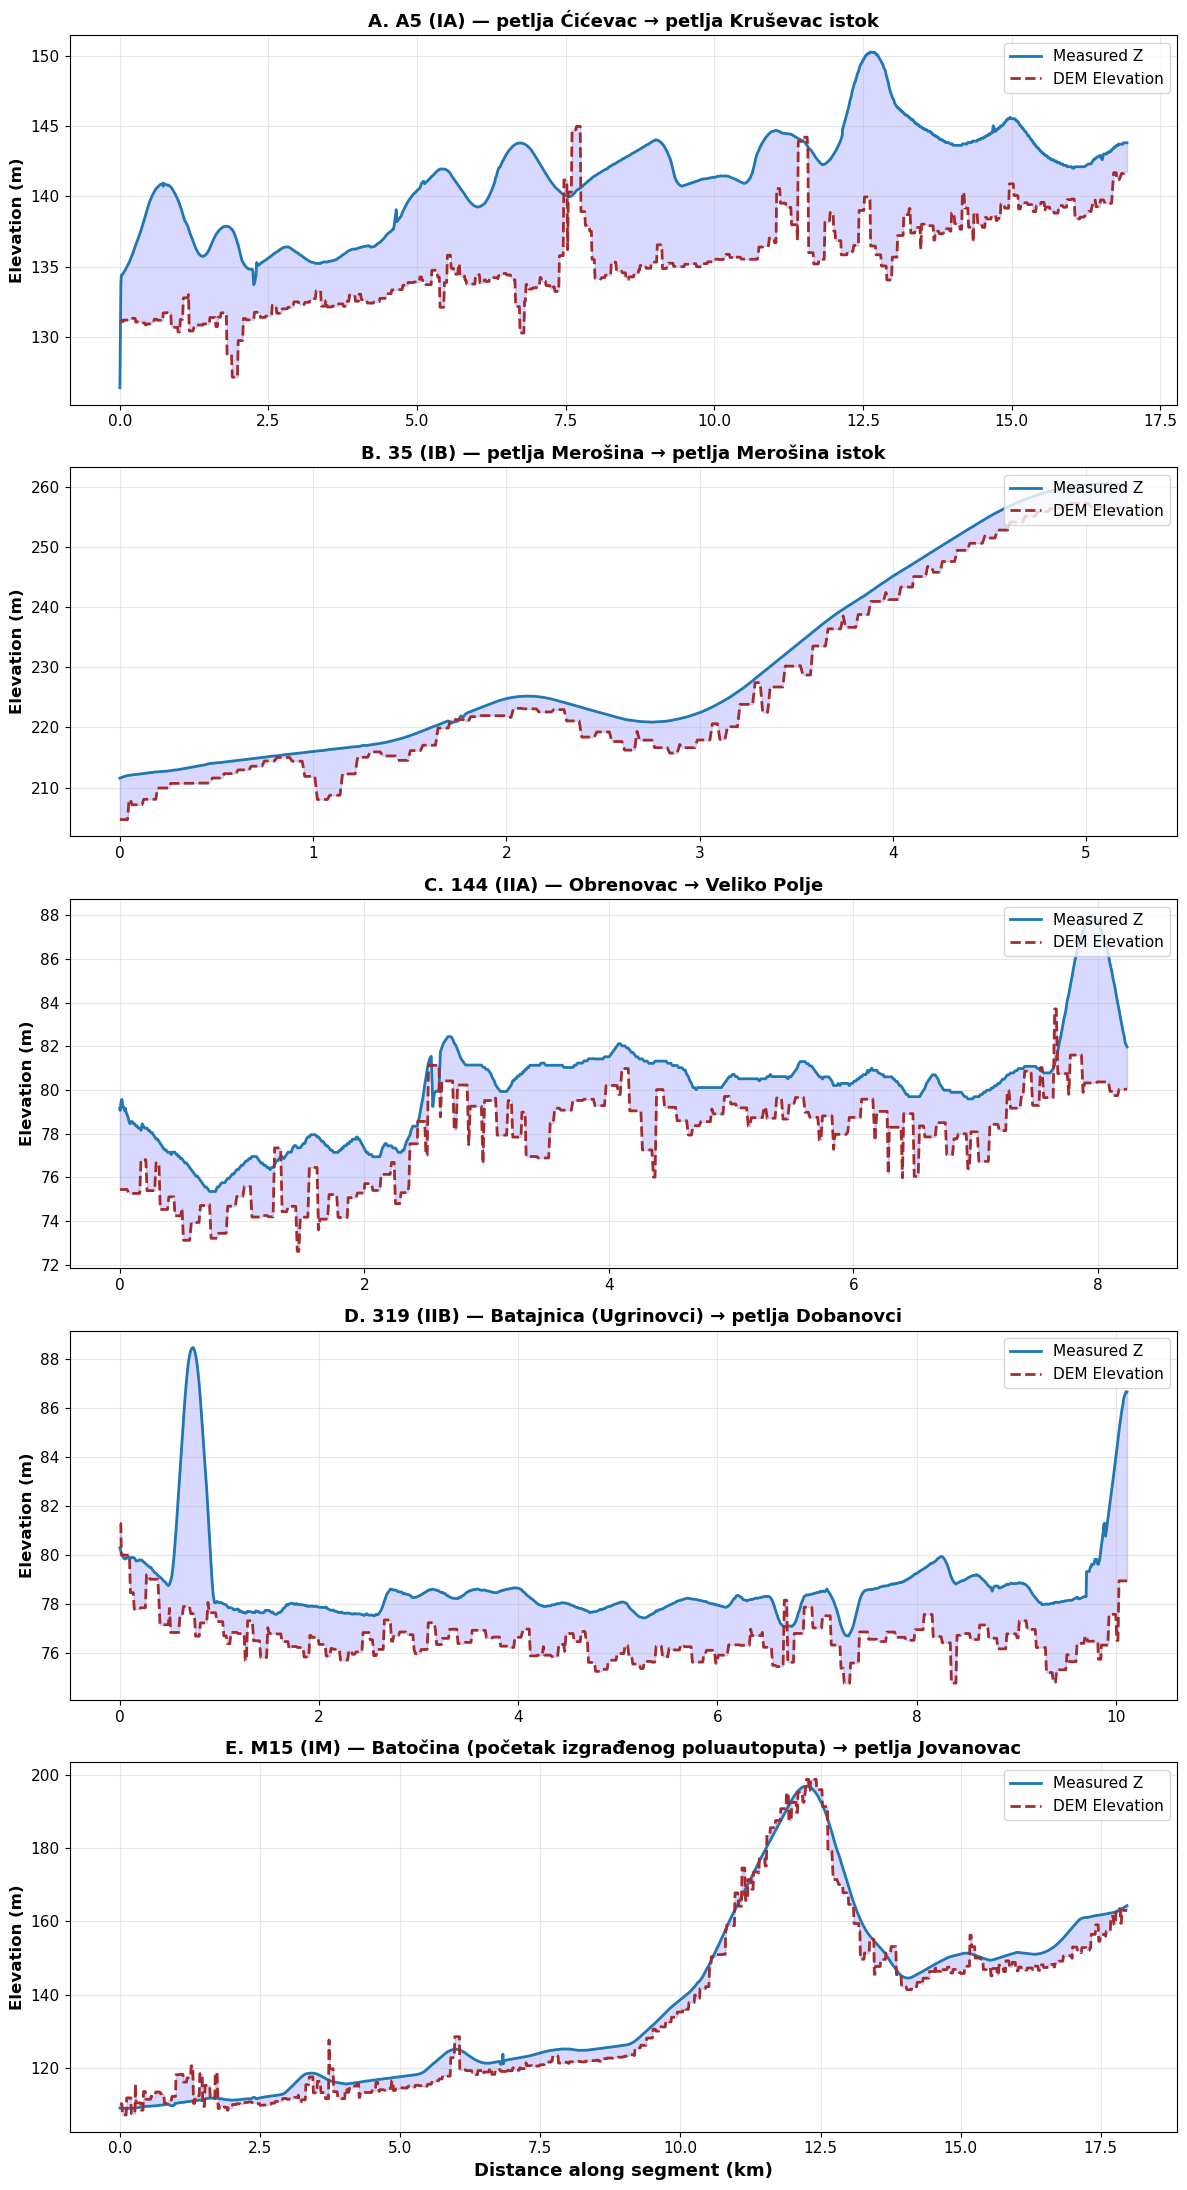

In [6]:
plot_elevation_profiles(vertical_coordinates, figure_path)

In [7]:
# Per-road bias statistics (measured Z minus DEM) and bootstrap 95% CIs per category
clean = compute_bias_statistics(vertical_coordinates)
ci_df = compute_bias_confidence_intervals(clean)

Roads with Z data: 151
Median bias per category: {'IA': 4.601053571428055, 'IB': 2.5885321098498104, 'IIA': 0.6095876782079163, 'IIB': 1.1351122123893485, 'IM': 3.659322115384341}
PutKateg  n   median  median_ci_low  median_ci_high      mean  mean_ci_low  mean_ci_high
      IA 35 4.601054       3.998717        5.591072  4.768886     4.207295      5.330478
      IB 22 2.588532       0.039983        3.422338  1.999851     0.807977      3.191724
     IIA 35 0.609588      -0.863578        0.896040 -0.430597    -1.700040      0.838847
     IIB 13 1.135112      -0.664770        3.531355  0.471914    -3.496995      4.440824
      IM 42 3.659322       3.253271        4.375735  3.615684     2.889432      4.341937

Pooled IIA+IIB (n=48)
Median: 0.64 m
95% CI: [-0.31, 1.07]


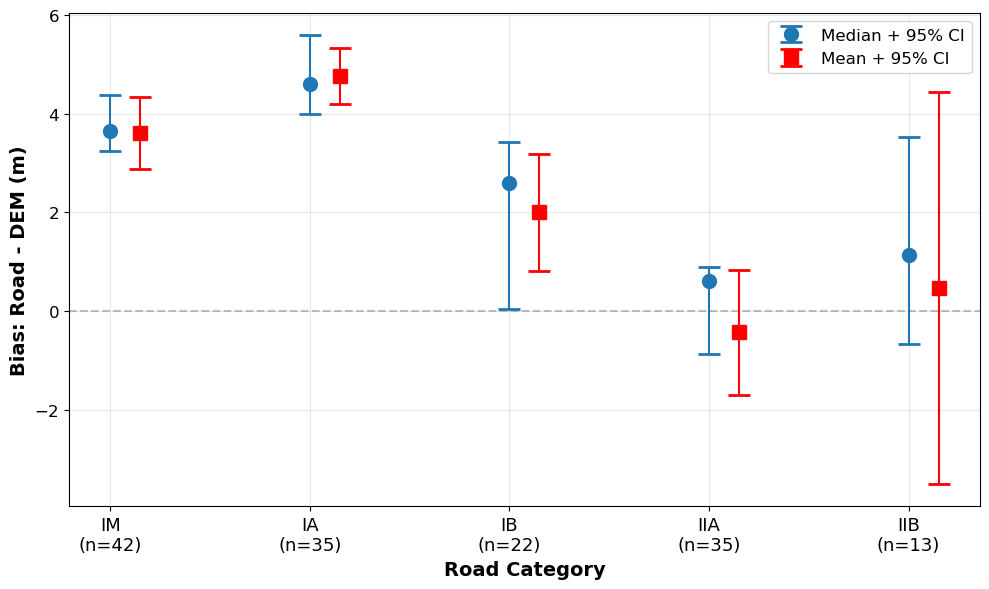

In [8]:
plot_elevation_bias(ci_df, figure_path)

In [9]:
# Apply the derived per-category elevation bias to the flood depths
print(f"Applied bias (m): {FINAL_ELEVATION_BIAS}")
exposed_roads = apply_bias_correction(exposed_roads)

Applied bias (m): {'IA': 4.601, 'IM': 3.659, 'IB': 0.82, 'IIA': 0.82, 'IIB': 0.82}
kategorija  total  originally_flooded  still_flooded  bias  avg_original_depth  avg_corrected_depth  removed  pct_removed
        IA    416                 416             79 4.601            2.748440             0.429406      337         81.0
        IB    334                 334            315 0.820            4.994186             4.188814       19          5.7
       IIA    405                 405            349 0.820            4.003812             3.232356       56         13.8
       IIB    108                 108             90 0.820            3.533222             2.764139       18         16.7
        IM     53                  53             18 3.659            3.380321             1.027906       35         66.0


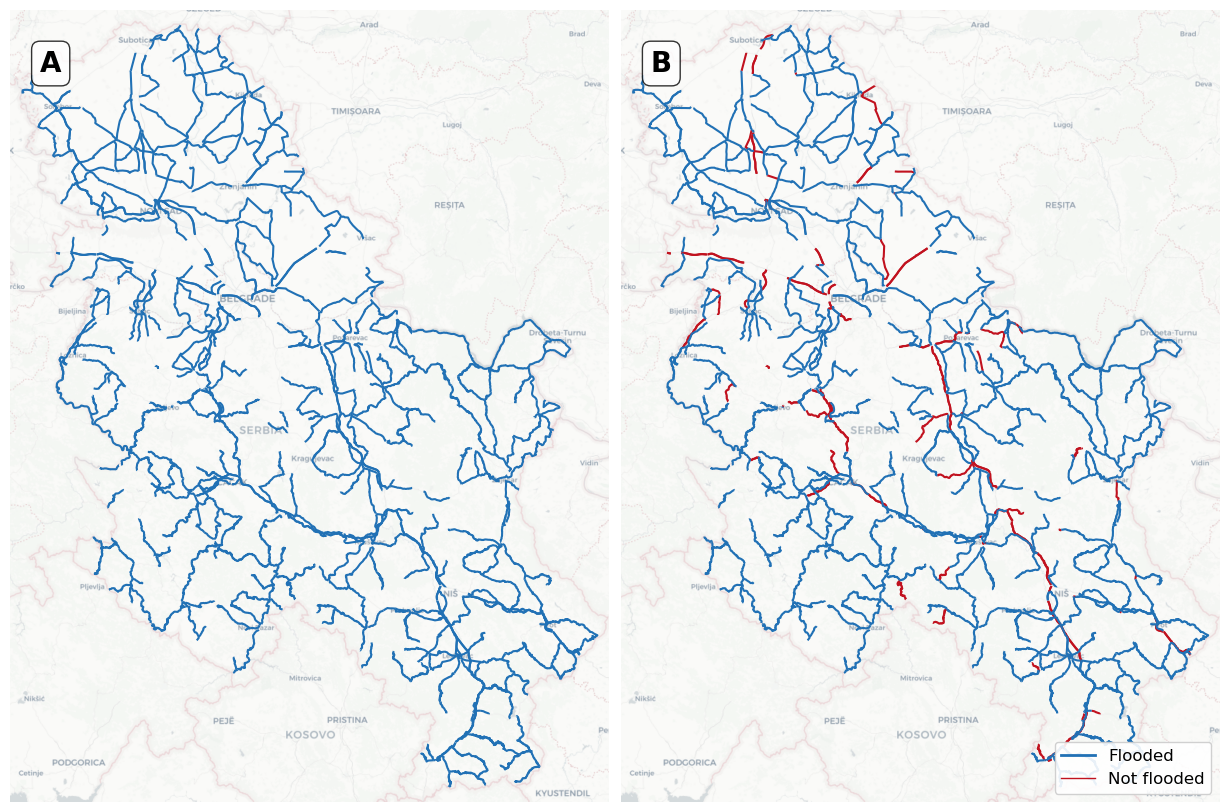

In [10]:
plot_flood_exposure_correction(exposed_roads, country_plot, figure_path)

## Flood-Exposed Roads With Criticality

In [11]:
corrected_roads = exposed_roads.loc[exposed_roads.corrected_max_depth > 0]
gdf_vhl_flooded = gdf_results.merge(
    corrected_roads.loc[corrected_roads.exposed][["coverage", "values", "corrected_max_depth"]],
    left_index=True,
    right_index=True,
)

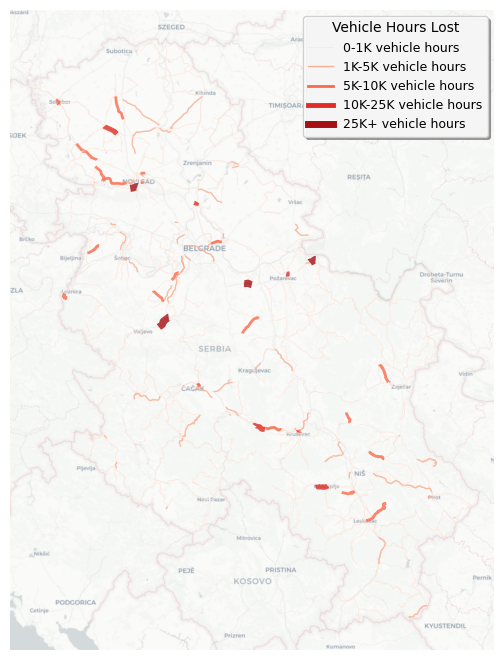

In [12]:
plot_vhl_flooded_map(gdf_vhl_flooded, figure_path)

## Other Hazard Overlays

In [13]:
# Snow drift: spatial join of road segments with snow-drift locations
gdf_vhl_snowdrift = calculate_vhl_snowdrift(gdf_results, data_path / "snezni_nanosi_studije.shp")

c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(


In [14]:
# Landslides: tip=='Klizište' only, 10 m buffer
gdf_vhl_landslides = calculate_vhl_landslides(gdf_results, data_path / "Nestabilne_pojave.shp")

In [15]:
# Wildfire: binary exposure (any susceptibility class > 0) via DamageScanner
gdf_vhl_wildfire = calculate_wildfire_exposure(
    gdf_results,
    wildfire_path=data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif",
    world_path=data_path / "ne_10m_admin_0_countries.shp",
)

Overlay raster with vector: 100%|██████████| 49/49 [00:25<00:00,  1.92it/s]


In [16]:
# Heat: max future pavement temperature (UHI raster) per road segment
gdf_vhl_heat = calculate_heat_exposure(
    gdf_results, intermediate_results_path / "future_pavement_temperatures.tif"
)

## Combine Hazards and Save

In [17]:
gdf_hazards = combine_hazard_exposure(
    gdf_results, gdf_vhl_flooded, gdf_vhl_snowdrift,
    gdf_vhl_landslides, gdf_vhl_wildfire, gdf_vhl_heat,
)

save_criticality_vector(
    gdf_hazards,
    parquet_dir=parquet_dir,
    gdb_path=gdb_path,
    layer_name="main_network_hazard_exposure",
    output_crs=output_crs,
)

Saved main_network_hazard_exposure -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\intermediate_results\parquet\hazard_exposure\main_network_hazard_exposure.parquet
Saved main_network_hazard_exposure -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\intermediate_results\database\hazard_exposure\hazard_exposure.gdb (layer 'main_network_hazard_exposure')
Saved Excel -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\intermediate_results\excel\hazard_exposure\main_network_hazard_exposure.xlsx


### Map of main network impacts

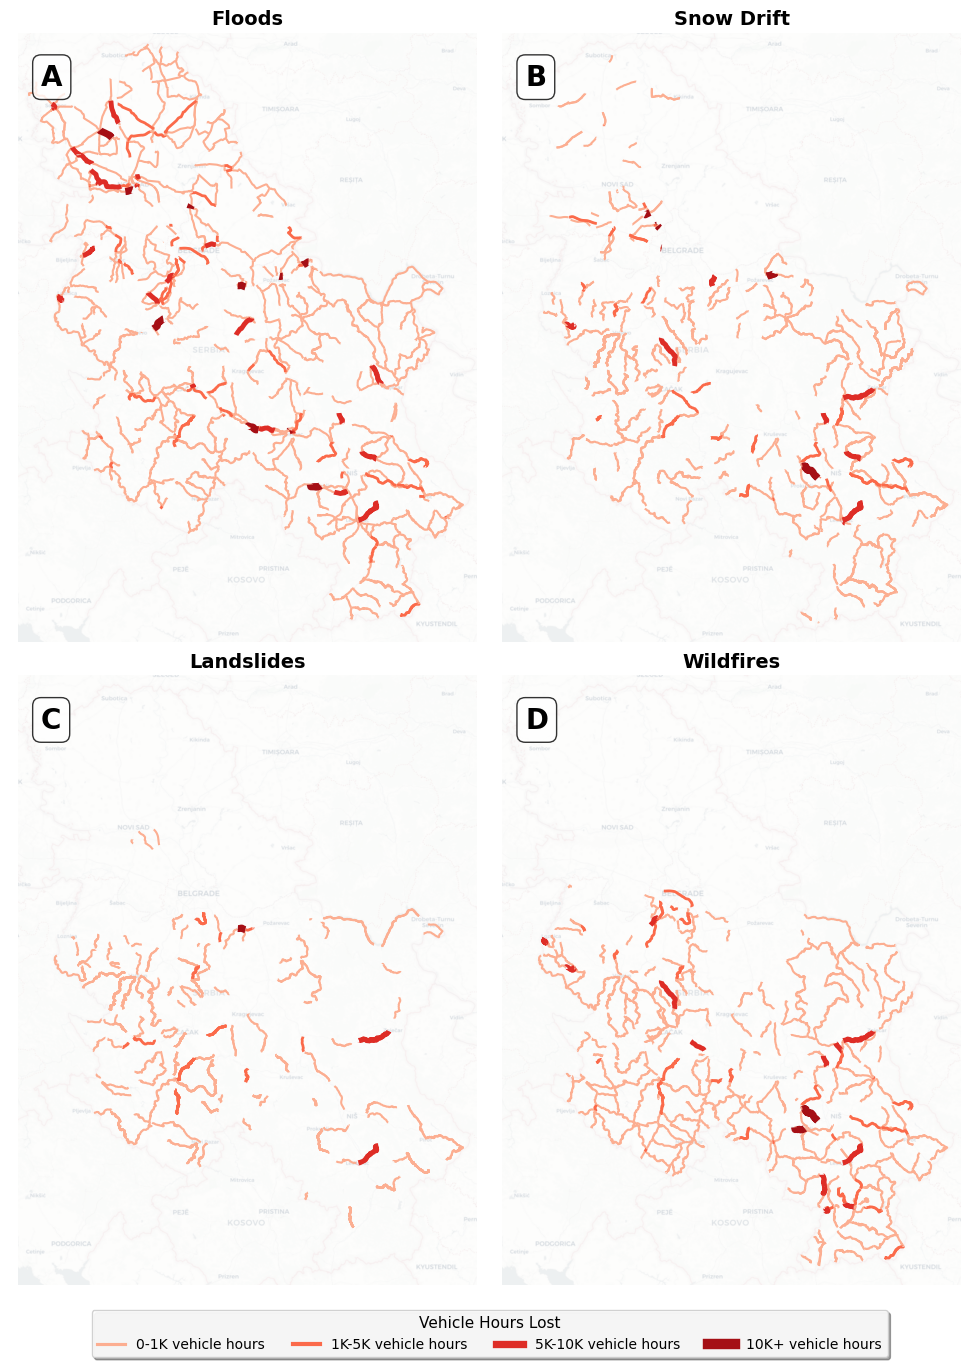

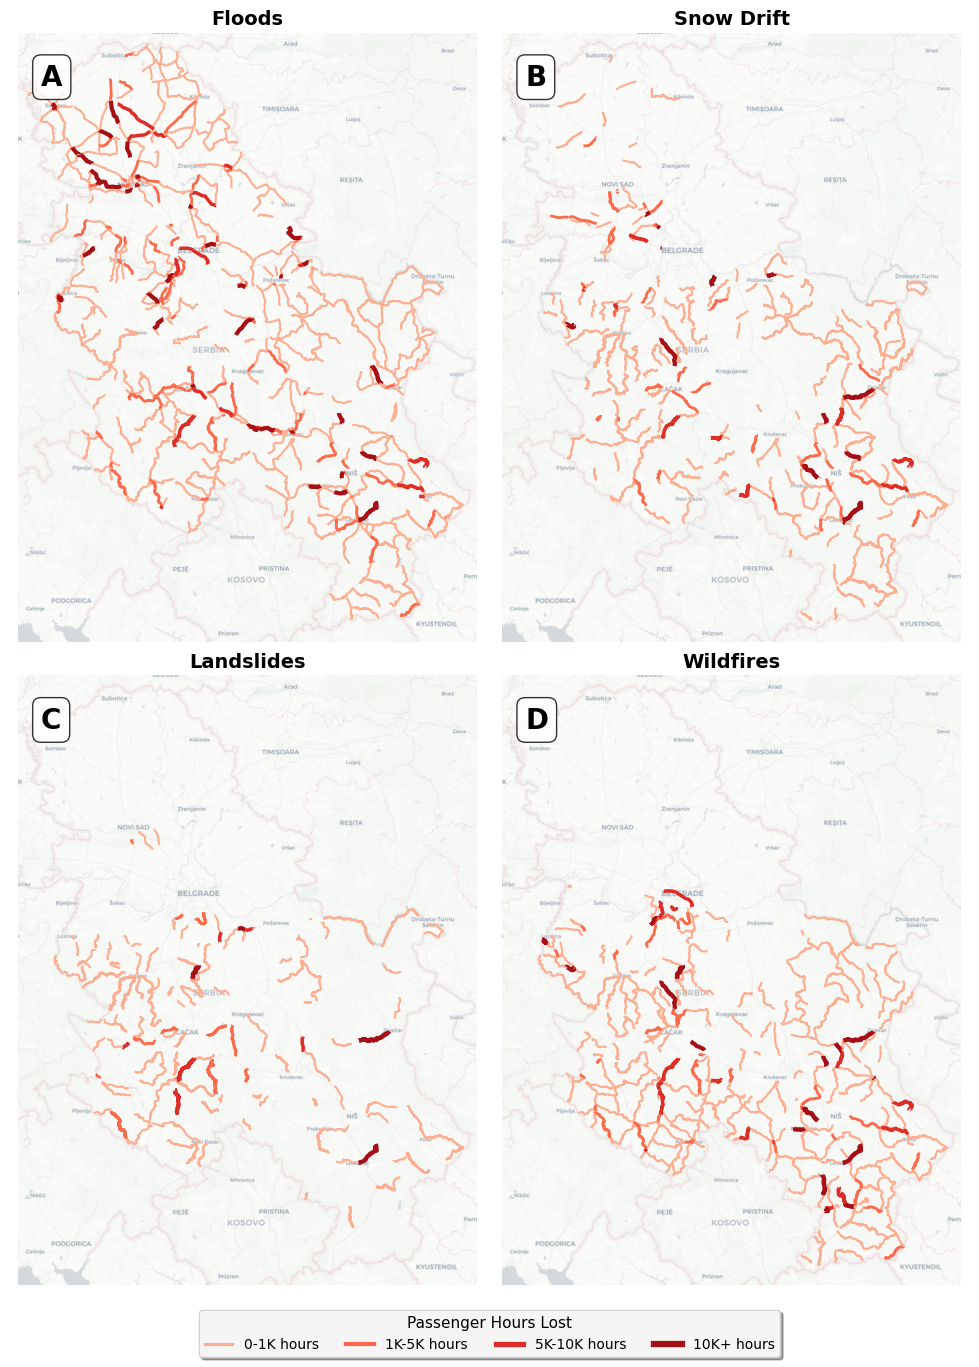

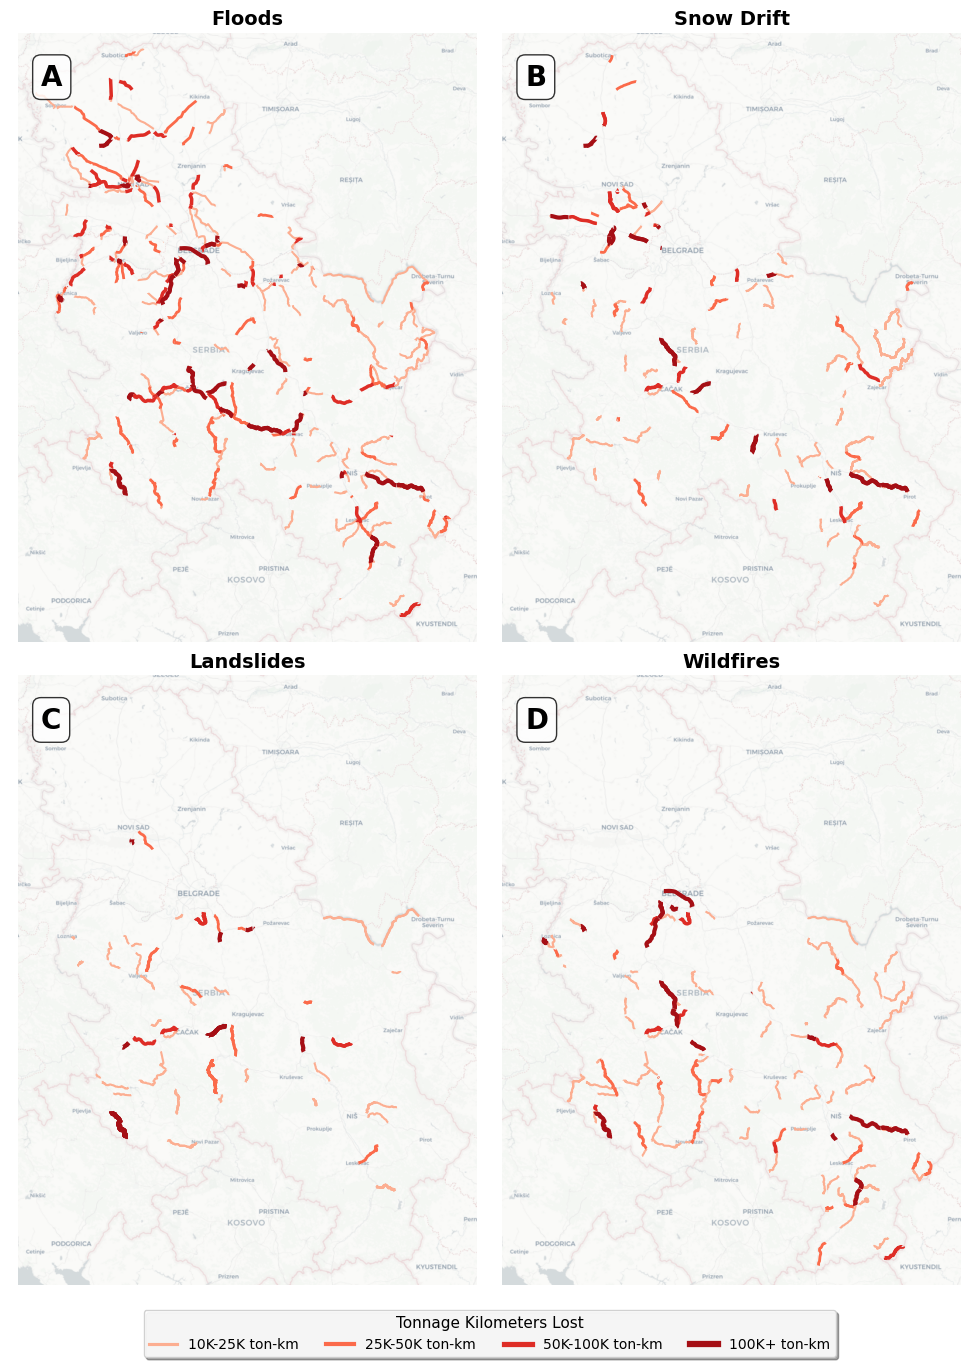

In [18]:
# 2x2 hazard comparison figures for VHL, PHL and TKL
plot_all_hazard_comparisons(
    gdf_vhl_flooded, gdf_vhl_snowdrift, gdf_vhl_landslides,
    gdf_vhl_wildfire, country_plot, figure_path,
)

In [19]:
# Deduplicate to one representative row per road section (oznaka_deo) — the same
# step applied in 5d before scoring — so the statistics below (and the multi-hazard
# overlay) reflect the final, deduplicated result scheme instead of raw segments.
# Attributes/geometry come from the longest segment, road_length is summed, and
# every disruption metric is aggregated with max (worst case) within each section.
gdf_results_dedup = deduplicate_by_section(gdf_results)
gdf_vhl_flooded_dedup = deduplicate_by_section(gdf_vhl_flooded)
gdf_vhl_snowdrift_dedup = deduplicate_by_section(
    gdf_vhl_snowdrift.rename(columns={"oznaka_deo_left": "oznaka_deo"})
)
gdf_vhl_landslides_dedup = deduplicate_by_section(
    gdf_vhl_landslides.rename(columns={"oznaka_deo_left": "oznaka_deo"})
)
gdf_vhl_wildfire_dedup = deduplicate_by_section(gdf_vhl_wildfire)

Deduplicated by oznaka_deo: 3217 -> 1809 rows (1408 collapsed; 0 remaining dups)
Deduplicated by oznaka_deo: 851 -> 750 rows (101 collapsed; 0 remaining dups)
Deduplicated by oznaka_deo: 464 -> 324 rows (140 collapsed; 0 remaining dups)
Deduplicated by oznaka_deo: 280 -> 144 rows (136 collapsed; 0 remaining dups)
Deduplicated by oznaka_deo: 402 -> 400 rows (2 collapsed; 0 remaining dups)


In [20]:
print_hazard_analysis_summary(
    gdf_results_dedup, gdf_vhl_flooded_dedup, gdf_vhl_snowdrift_dedup,
    gdf_vhl_landslides_dedup, gdf_vhl_wildfire_dedup,
)

BASELINE RESULTS - ALL METRICS

Total road segments analyzed: 1,809

All Metrics Summary:
             phl        thl         pkl         tkl
count    1743.00    1743.00     1743.00     1743.00
mean     2516.53    1408.96   114037.25    75321.40
std      7198.97    4504.48   263555.71   231340.36
min         0.00       0.00        0.00        0.00
25%       144.15      40.86    11828.66     3485.31
50%       422.35     143.88    34431.54    12145.21
75%      1611.86     743.45    97682.82    40750.89
max    148457.21  100462.97  4285359.57  3807947.23

Totals across network:
  Total PHL: 4,386,311 passenger hours
  Total THL: 2,455,814 ton hours
  Total PKL: 198,766,931 passenger km
  Total TKL: 131,285,199 ton km

PASSENGER HOURS LOST (PHL) BY HAZARD

──────────────────────────────────────────────────
FLOODS
──────────────────────────────────────────────────
Exposed road segments: 750
count       727.00
mean       2145.17
std        7832.05
min           0.00
25%         123.78
50%   

## Multi-Hazard Exposure Count

Binary yes/no exposure across six hazards (flood, snow drift, landslide, wildfire, pavement heat > 60°C, projected extreme-rainfall change ≥ 10%), mapped by how many hazards affect each road section. Segments are deduplicated to one row per `oznaka_deo` (matching the final result scheme) before counting, so a section counts as exposed to a hazard if any of its segments is.


Deduplicated by oznaka_deo: 3217 -> 1809 rows (1408 collapsed; 0 remaining dups)


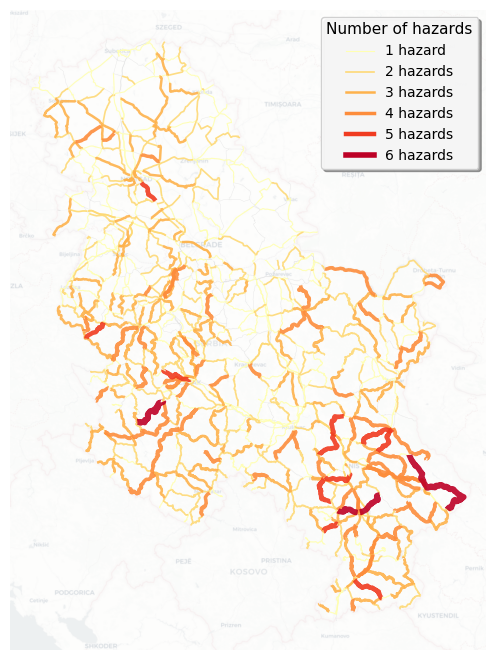

MULTI-HAZARD EXPOSURE SUMMARY
Total road segments in network: 1809

Roads exposed per hazard:
  Flood                             :    750  ( 41.5% of network)
  Snow drift                        :    324  ( 17.9% of network)
  Landslide                         :    144  (  8.0% of network)
  Wildfire                          :    400  ( 22.1% of network)
  Heat (pavement > 60°C)            :    441  ( 24.4% of network)
  Future precipitation (≥ 10% change):    526  ( 29.1% of network)

Roads by number of hazards:
  0 hazard(s):    391  ( 21.6% of network)
  1 hazard(s):    673  ( 37.2% of network)
  2 hazard(s):    431  ( 23.8% of network)
  3 hazard(s):    225  ( 12.4% of network)
  4 hazard(s):     74  (  4.1% of network)
  5 hazard(s):     11  (  0.6% of network)
  6 hazard(s):      4  (  0.2% of network)

Roads exposed to at least one hazard: 1418 (78.4% of network)


In [21]:
# Binary exposure flag per hazard, then a per-segment hazard count
hazard_specs = [
    ("hazard_flood", "Flood", gdf_results.index.isin(gdf_vhl_flooded.index)),
    ("hazard_snow_drift", "Snow drift", gdf_results.index.isin(gdf_vhl_snowdrift.index)),
    ("hazard_landslide", "Landslide", gdf_results.index.isin(gdf_vhl_landslides.index)),
    ("hazard_wildfire", "Wildfire", gdf_results.index.isin(gdf_vhl_wildfire.index)),
    ("hazard_heat", "Heat (pavement > 60°C)",
     (gdf_vhl_heat["max_pavement_temp"] > 60).reindex(gdf_results.index, fill_value=False).to_numpy()),
    ("hazard_future_precipitation", "Future precipitation (≥ 10% change)",
     flag_future_precipitation(
         gdf_results,
         parquet_dir / "change in maximum daily precipitation rcp 85 period 2.parquet",
         threshold=10.0,
     )),
]

gdf_hazard_count = build_hazard_count(gdf_results, hazard_specs)

# Deduplicate to one row per road section (oznaka_deo) so the multi-hazard counts
# match the final result scheme (see 5d). The binary hazard flags are aggregated
# with max (a section is exposed if any of its segments is), then the per-section
# hazard count is recomputed from those deduplicated flags.
hazard_cols = [col for col, _, _ in hazard_specs]
gdf_hazard_count = deduplicate_by_section(gdf_hazard_count)
gdf_hazard_count["hazard_count"] = gdf_hazard_count[hazard_cols].sum(axis=1)

plot_hazard_count_map(gdf_hazard_count, figure_path, n_hazards=len(hazard_specs))
summarize_hazard_counts(gdf_hazard_count, hazard_specs)


In [22]:
all_six = gdf_hazard_count[gdf_hazard_count["hazard_count"] == 6]
print(all_six[["oznaka_deo", "kategorija", "oznaka_put", "naziv_poce", "naziv_zavr"]].to_string(index=False))


oznaka_deo kategorija oznaka_put             naziv_poce                 naziv_zavr
     22603        IIA        226               Dragovac Leskovac (Gornje Stopanje)
     19602        IIA        196                 Arilje                    Čubraci
   22103o1        IIA        221                Jalovik                          /
     43701        IIB        437 Leskovac (Bratmilovce)           Gornje Dragovlje
